In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Display all columns
pd.set_option('display.max_columns', None)

In [3]:
# Load datasets
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

In [4]:
# Quick check
print("Customers Shape:", customers.shape)
print("Orders Shape:", orders.shape)
print("Items Shape:", items.shape)
print("Payments Shape:", payments.shape)
print("Reviews Shape:", reviews.shape)
print("Products Shape:", products.shape)
print("Sellers Shape:", sellers.shape)

Customers Shape: (99441, 5)
Orders Shape: (99441, 8)
Items Shape: (112650, 7)
Payments Shape: (103886, 5)
Reviews Shape: (99224, 7)
Products Shape: (32951, 9)
Sellers Shape: (3095, 4)


In [5]:
orders.head()
customers.head()
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [9]:
# Copy dataframe (safe habit)
orders_clean = orders.copy()

In [10]:
# Convert date columns to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

In [11]:
# Check data types after conversion
print(orders_clean.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [12]:
# Missing values count
print("\nMissing Values:")
print(orders_clean.isnull().sum())


Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [13]:
# Order status counts
print("\nOrder Status Counts:")
print(orders_clean['order_status'].value_counts())


Order Status Counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [14]:
# Preview cleaned table
orders_clean.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [16]:
#Checking why delivery date few cells are missing
orders_clean[
    orders_clean['order_delivered_customer_date'].isnull()
]['order_status'].value_counts()

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


In [17]:
# Keep only delivered orders
delivered_orders = orders_clean[
    orders_clean['order_status'] == 'delivered'
].copy()

In [18]:
# Check shape
print(delivered_orders.shape)

(96478, 8)


In [19]:
# Missing values in delivered orders
print(delivered_orders.isnull().sum())

# Preview
delivered_orders.head()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [20]:
# Delivery days actual
delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date'] -
    delivered_orders['order_purchase_timestamp']
).dt.days

# Approval delay
delivered_orders['approval_days'] = (
    delivered_orders['order_approved_at'] -
    delivered_orders['order_purchase_timestamp']
).dt.days

# Estimated vs actual
delivered_orders['estimated_days'] = (
    delivered_orders['order_estimated_delivery_date'] -
    delivered_orders['order_purchase_timestamp']
).dt.days

In [21]:
# Show summary
delivered_orders[['delivery_days','approval_days','estimated_days']].describe()

,delivery_days,approval_days,estimated_days
count,96470.000000,96464.000000,96478.000000
mean,12.093604,0.264337,23.372759
std,9.551380,0.729926,8.758137
min,0.000000,0.000000,2.000000
25%,6.000000,0.000000,18.000000
50%,10.000000,0.000000,23.000000
75%,15.000000,0.000000,28.000000
max,209.000000,30.000000,155.000000


In [23]:
# Late delivery flag
delivered_orders['is_late'] = (
    delivered_orders['order_delivered_customer_date'] >
    delivered_orders['order_estimated_delivery_date']
)

# Convert True/False to counts
late_counts = delivered_orders['is_late'].value_counts()

print(late_counts)

is_late
False    88652
True      7826
Name: count, dtype: int64


In [24]:
# Late delivery percentage
late_pct = delivered_orders['is_late'].mean() * 100
print(f"Late Delivery %: {late_pct:.2f}%")

Late Delivery %: 8.11%


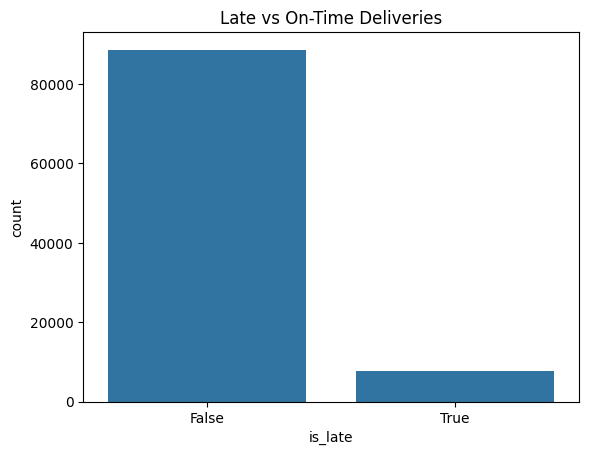

In [25]:
sns.countplot(data=delivered_orders, x='is_late')
plt.title("Late vs On-Time Deliveries")
plt.show()

In [26]:
# Merge delivered orders with customers
orders_customers = delivered_orders.merge(
    customers,
    on='customer_id',
    how='left'
)

In [27]:
# Late % by state
state_late = (
    orders_customers
    .groupby('customer_state')['is_late']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

In [28]:
# Convert to %
state_late['is_late'] = state_late['is_late'] * 100

print(state_late.head(10))

  customer_state    is_late
0             AL  23.929471
1             MA  19.665272
2             PI  15.966387
3             CE  15.324472
4             SE  15.223881
5             BA  14.035627
6             RJ  13.473684
7             TO  12.773723
8             PA  12.367865
9             ES  12.230576


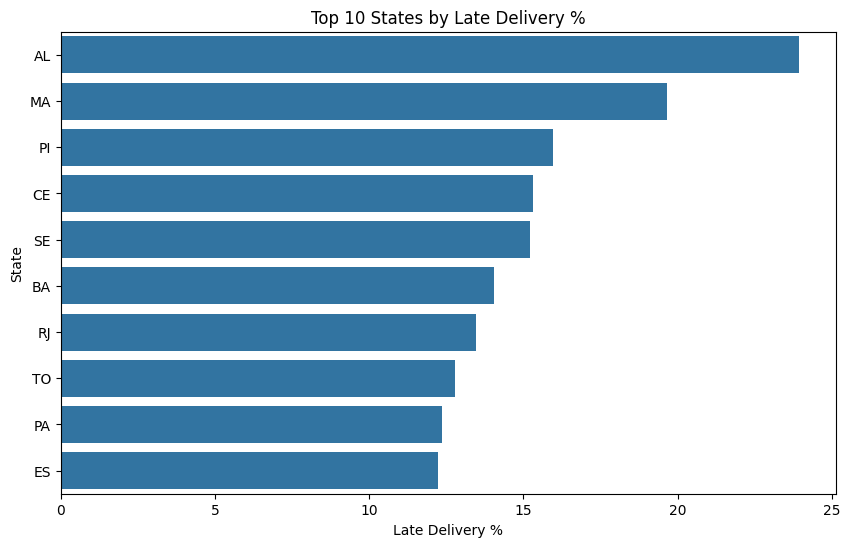

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(data=state_late.head(10), x='is_late', y='customer_state')
plt.title("Top 10 States by Late Delivery %")
plt.xlabel("Late Delivery %")
plt.ylabel("State")
plt.show()

In [30]:
# Merge delivered orders with reviews
delivery_reviews = delivered_orders.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

# Average review by late/on-time
review_impact = (
    delivery_reviews
    .groupby('is_late')['review_score']
    .mean()
    .reset_index()
)

print(review_impact)

   is_late  review_score
0    False      4.293737
1     True      2.566494


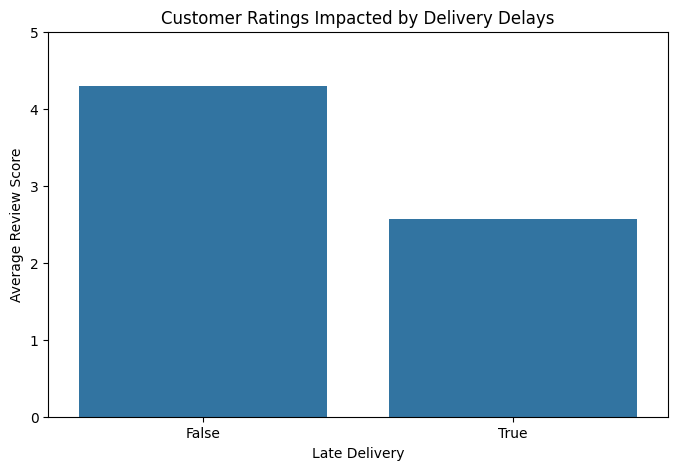

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(data=review_impact, x='is_late', y='review_score')
plt.title("Customer Ratings Impacted by Delivery Delays")
plt.xlabel("Late Delivery")
plt.ylabel("Average Review Score")
plt.ylim(0,5)
plt.show()

In [33]:
# Merge delivered orders with order items
cat_delay = delivered_orders.merge(
    items[['order_id', 'product_id']],
    on='order_id',
    how='left'
)

# Merge with products table
cat_delay = cat_delay.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# Merge with translation table
cat_delay = cat_delay.merge(
    translation,
    on='product_category_name',
    how='left'
)

In [34]:
# Use English names
cat_delay['category'] = cat_delay['product_category_name_english']

In [35]:
# Group by category
category_late = (
    cat_delay
    .groupby('category')['is_late']
    .agg(['mean', 'count'])
    .reset_index()
)

In [36]:
# Rename columns
category_late.columns = ['category', 'late_rate', 'orders']

In [37]:
# Keep categories with enough volume
category_late = category_late[category_late['orders'] >= 100]

In [38]:
# Convert to %
category_late['late_rate'] = category_late['late_rate'] * 100

In [39]:
# Sort highest late %
category_late = category_late.sort_values(
    by='late_rate',
    ascending=False
)

print(category_late.head(10))

                     category  late_rate  orders
4                       audio  12.707182     362
33    fashion_underwear_beach  12.598425     127
12         christmas_supplies  12.000000     150
10            books_technical  11.026616     263
47               home_confort  10.256410     429
18  construction_tools_lights   9.966777     301
36                       food   9.819639     499
26                electronics   9.747160    2729
43              health_beauty   9.054411    9465
57           office_furniture   8.932854    1668


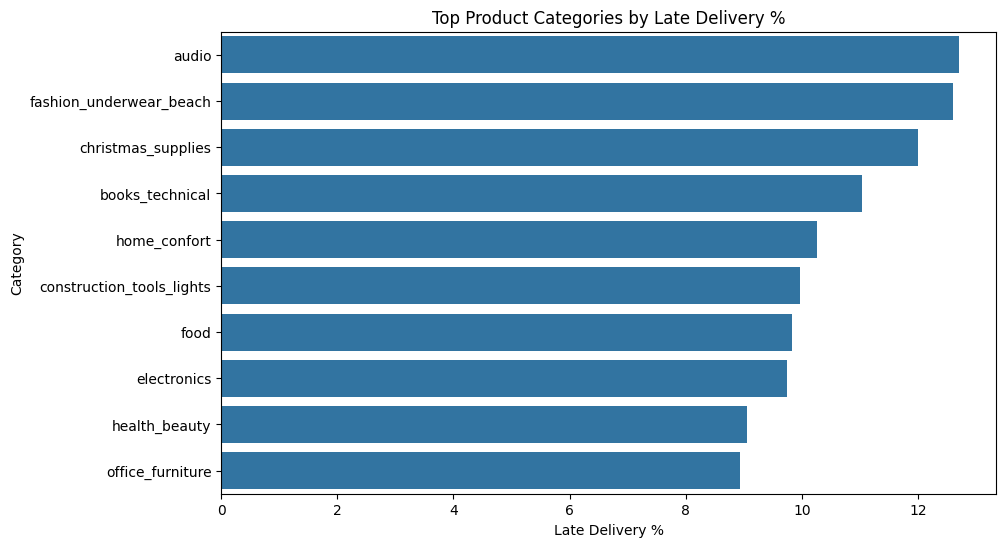

In [40]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=category_late.head(10),
    x='late_rate',
    y='category'
)
plt.title("Top Product Categories by Late Delivery %")
plt.xlabel("Late Delivery %")
plt.ylabel("Category")
plt.show()

In [41]:
# Merge delivered orders with items
revenue_data = delivered_orders.merge(
    items[['order_id', 'product_id', 'price']],
    on='order_id',
    how='left'
)

In [42]:
# Extract month
revenue_data['purchase_month'] = (
    revenue_data['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

In [43]:
# Monthly revenue
monthly_revenue = (
    revenue_data
    .groupby('purchase_month')['price']
    .sum()
    .reset_index()
)

print(monthly_revenue.head())

  purchase_month      price
0        2016-09     134.97
1        2016-10   40325.11
2        2016-12      10.90
3        2017-01  111798.36
4        2017-02  234223.40


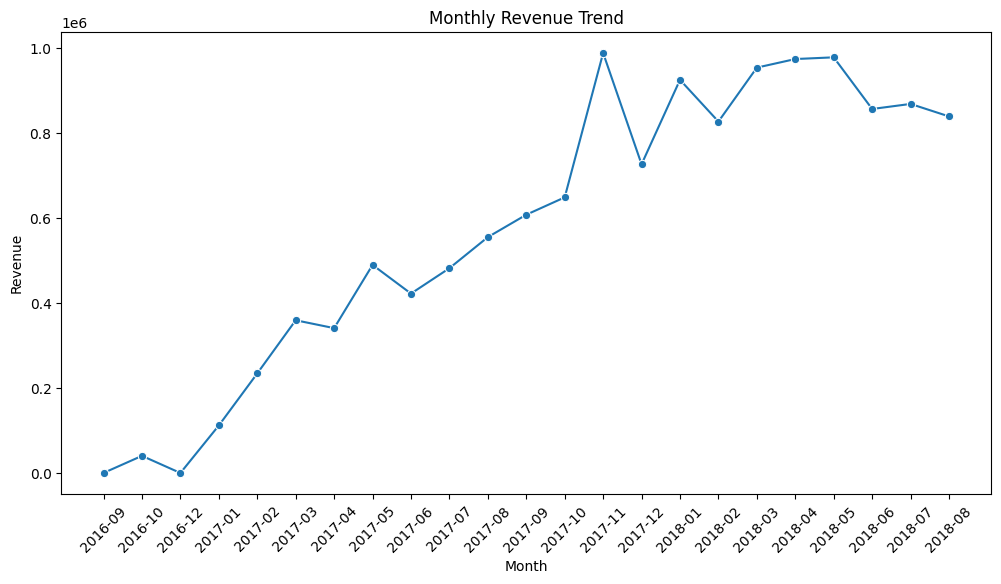

In [44]:
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_revenue, x='purchase_month', y='price', marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [45]:
# Add product category
category_revenue = revenue_data.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# Translate to English
category_revenue = category_revenue.merge(
    translation,
    on='product_category_name',
    how='left'
)

In [46]:
# Group by category
top_categories = (
    category_revenue
    .groupby('product_category_name_english')['price']
    .sum()
    .reset_index()
)

# Rename columns
top_categories.columns = ['category', 'revenue']

# Sort descending
top_categories = top_categories.sort_values(
    by='revenue',
    ascending=False
)

print(top_categories.head(10))

                 category     revenue
43          health_beauty  1233131.72
70          watches_gifts  1166176.98
7          bed_bath_table  1023434.76
65         sports_leisure   954852.55
15  computers_accessories   888724.61
39        furniture_decor   711927.69
49             housewares   615628.69
20             cool_stuff   610204.10
5                    auto   578966.65
69                   toys   471286.48


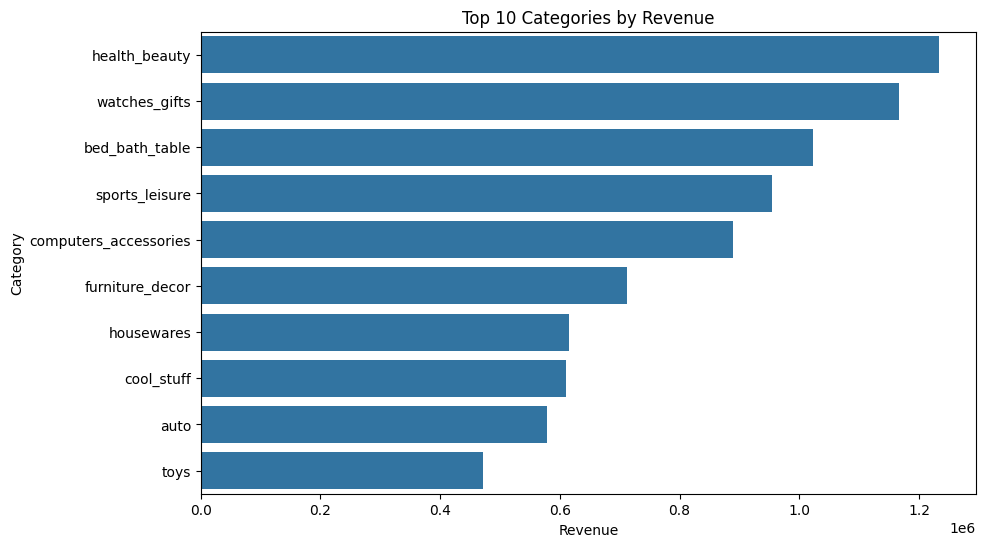

In [47]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_categories.head(10),
    x='revenue',
    y='category'
)
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

In [48]:
# Merge delivered orders with customers
cust_orders = delivered_orders.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

# Count orders per unique customer
customer_frequency = (
    cust_orders
    .groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index()
)

customer_frequency.columns = ['customer_unique_id', 'num_orders']

print(customer_frequency.head())

                 customer_unique_id  num_orders
0  0000366f3b9a7992bf8c76cfdf3221e2           1
1  0000b849f77a49e4a4ce2b2a4ca5be3f           1
2  0000f46a3911fa3c0805444483337064           1
3  0000f6ccb0745a6a4b88665a16c9f078           1
4  0004aac84e0df4da2b147fca70cf8255           1


In [49]:
# Label customer type
customer_frequency['customer_type'] = np.where(
    customer_frequency['num_orders'] > 1,
    'Repeat',
    'One-Time'
)

# Count customers
retention_summary = (
    customer_frequency['customer_type']
    .value_counts()
    .reset_index()
)

retention_summary.columns = ['customer_type', 'count']

# Percentage
retention_summary['percentage'] = (
    retention_summary['count'] /
    retention_summary['count'].sum()
) * 100

print(retention_summary)

  customer_type  count  percentage
0      One-Time  90557   96.999722
1        Repeat   2801    3.000278


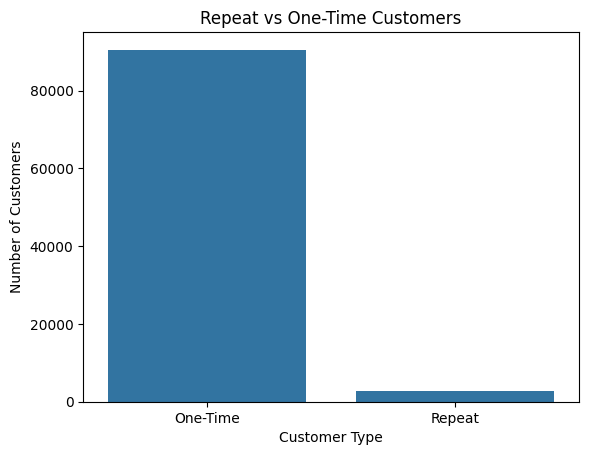

In [50]:
sns.barplot(data=retention_summary, x='customer_type', y='count')
plt.title("Repeat vs One-Time Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.show()

In [51]:
print("Average Orders Per Customer:",
      round(customer_frequency['num_orders'].mean(),2))

Average Orders Per Customer: 1.03
